# Обучение с использованием REINFORCE для Mujoco

В этом руководстве мы реализуем REINFORCE с использованием нейронных сетей для среды Mujoco.

Мы будем использовать **REINFORCE**, один из самых ранних методов градиентного спуска для построения политики. В отличие от необходимости сначала обучать функцию ценности, а затем выводить из нее политику,
REINFORCE оптимизирует политику напрямую. Другими словами, он обучается для максимизации вероятности возврата Монте-Карло. Подробнее об этом позже.

**Перевернутый маятник** — это тележка-шест из Mujoco, но теперь работающая на основе физического симулятора Mujoco,
что позволяет проводить более сложные эксперименты (например, изменять влияние гравитации).
Эта среда включает в себя тележку, которая может перемещаться линейно, с шестом, закрепленным на одном конце, и свободным другим концом.
Тележку можно толкать влево или вправо, и цель состоит в том, чтобы уравновесить шест на верхней части тележки, прикладывая к ней силы.

Более подробную информацию об окружении можно найти по адресу https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/

**Цели обучения**: Уравновешивание шеста (перевернутого маятника) на тележке.

**Действия**: Агент использует одномерный вектор для действий. Пространство действий представляет собой непрерывную последовательность «(действие)» в диапазоне «[-3, 3]»,
где действие представляет собой числовую силу, приложенную к тележке,
(где величина представляет собой величину силы, а знак — направление).

**Подход**: Мы используем PyTorch для написания кода REINFORCE с нуля для обучения нейронной сети управлению перевернутым маятником.

Объяснение функции `Env.step()` в Gymnasium v0.26+:

``env.step(A)`` позволяет нам выполнить действие 'A' в текущей среде 'env'. Затем среда выполняет действие и возвращает пять переменных:

- ``next_obs``: это наблюдение, которое агент получит после выполнения действия.

- ``reward``: это награда, которую агент получит после выполнения действия.

- ``terminated``: это логическая переменная, указывающая, завершилась ли работа среды.

- ``truncated``: это логическая переменная, которая также указывает, завершился ли эпизод досрочно, то есть был ли достигнут лимит времени.

- ``info``: это словарь, который может содержать дополнительную информацию об среде.


In [1]:
pip install "gymnasium[mujoco]"  # подгрузим в google collab игру gymnasium[mujoco]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 19.4 MB/s eta 0:00:00


In [2]:
from __future__ import annotations  # позволяет использовать аннотации типов до их объявления

import random  # модуль для генерации случайных чисел
import matplotlib.pyplot as plt  # библиотека для построения графиков
import numpy as np  # библиотека для работы с массивами и математикой
import pandas as pd  # библиотека для работы с таблицами и данными
import seaborn as sns  # библиотека для красивой визуализации данных
import torch  # основная библиотека PyTorch для машинного обучения
import torch.nn as nn  # модуль нейронных сетей PyTorch
from torch.distributions.normal import Normal  # класс нормального распределения
import gymnasium as gym  # библиотека сред для обучения с подкреплением

plt.rcParams["figure.figsize"] = (10, 5)  # устанавливает размер графиков matplotlib

## Сеть политик

Начнем с построения политики, которую агент будет изучать с помощью REINFORCE.

Политика — это отображение от текущего наблюдения за окружающей средой к вероятностному распределению действий, которые необходимо предпринять.

Политика, используемая в этом руководстве, параметризуется нейронной сетью. Она состоит из двух линейных слоев, которые используются совместно для прогнозируемого среднего значения и стандартного отклонения.

Кроме того, отдельные линейные слои используются для оценки среднего значения и стандартного отклонения. ``nn.Tanh`` используется в качестве нелинейности между скрытыми слоями.

Следующая функция оценивает среднее значение и стандартное отклонение нормального распределения, из которого выбирается действие.

Следовательно, ожидается, что политика будет обучаться
соответствующим весам для вывода средних значений и стандартных отклонений на основе текущего наблюдения.



In [3]:
class Policy_Network(nn.Module):  # объявление класса нейронной сети политики

    """Parametrized Policy Network."""  # описание класса

    def __init__(self, obs_space_dims: int, action_space_dims: int):  # конструктор класса
        super().__init__()  # вызов конструктора родительского класса nn.Module

        hidden_space1 = 16  # количество нейронов в первом скрытом слое
        hidden_space2 = 32  # количество нейронов во втором скрытом слое

        self.shared_net = nn.Sequential(  # общая часть сети
            nn.Linear(obs_space_dims, hidden_space1),  # линейный слой: входное состояние -> 16 нейронов
            nn.Tanh(),  # функция активации tanh
            nn.Linear(hidden_space1, hidden_space2),  # линейный слой: 16 -> 32 нейрона
            nn.Tanh(),  # функция активации tanh
        )

        self.policy_mean_net = nn.Sequential(  # сеть для вычисления среднего значения действия
            nn.Linear(hidden_space2, action_space_dims)  # линейный слой: 32 -> размер пространства действий
        )

        self.policy_stddev_net = nn.Sequential(  # сеть для вычисления стандартного отклонения действия
            nn.Linear(hidden_space2, action_space_dims)  # линейный слой: 32 -> размер пространства действий
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:  # метод прямого прохода сети
        shared_features = self.shared_net(x.float())  # преобразуем вход в float и пропускаем через общую сеть
        action_means = self.policy_mean_net(shared_features)  # вычисляем среднее значение действия
        action_stddevs = torch.log(  # вычисляем стандартное отклонение
            1 + torch.exp(self.policy_stddev_net(shared_features))  # преобразование, чтобы значение было положительным
        )

        return action_means, action_stddevs  # возвращаем среднее и стандартное отклонение

## Создание агента

Теперь, когда мы закончили создание политики, давайте разработаем **REINFORCE**, который оживит сеть политики.
Алгоритм REINFORCE можно найти выше. Как упоминалось ранее, REINFORCE стремится максимизировать результаты Монте-Карло.

Интересный факт: REINFORCE — это аббревиатура от "RE", где "вознаграждение", "прирост", "неотрицательный", "фактор", "смещение", "подкрепление", "характеристика", "право на получение" (E).

Примечание: Выбор гиперпараметров обусловлен обучением агента с приемлемой производительностью. Обширной настройки гиперпараметров не проводилось.




In [4]:
class REINFORCE:  # класс агента, реализующего алгоритм REINFORCE

    def __init__(self, obs_space_dims: int, action_space_dims: int):  # конструктор агента
        self.learning_rate = 1e-4  # скорость обучения нейронной сети
        self.gamma = 0.99  # коэффициент дисконтирования будущих наград
        self.eps = 1e-6  # маленькое значение для предотвращения деления на ноль

        self.probs = []  # список для хранения логарифмов вероятностей действий
        self.rewards = []  # список для хранения полученных наград

        self.net = Policy_Network(obs_space_dims, action_space_dims)  # создаем нейронную сеть политики
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)  # оптимизатор AdamW

    def sample_action(self, state: np.ndarray) -> float:  # функция выбора действия
        state = torch.tensor(np.array([state]))  # преобразуем состояние среды в тензор PyTorch

        action_means, action_stddevs = self.net(state)  # получаем параметры распределения действий

        distrib = Normal(action_means[0] + self.eps, action_stddevs[0] + self.eps)  # создаем нормальное распределение

        action = distrib.sample()  # случайным образом выбираем действие из распределения

        prob = distrib.log_prob(action)  # вычисляем логарифм вероятности выбранного действия

        action = action.numpy()  # преобразуем действие обратно в numpy формат

        self.probs.append(prob)  # сохраняем вероятность действия

        return action  # возвращаем выбранное действие

    def update(self):  # функция обновления нейронной сети
        running_g = 0  # переменная для накопленной дисконтированной награды
        gs = []  # список для хранения дисконтированных наград

        for R in self.rewards[::-1]:  # перебираем награды в обратном порядке
            running_g = R + self.gamma * running_g  # вычисляем дисконтированную сумму наград
            gs.insert(0, running_g)  # добавляем значение в начало списка

        deltas = torch.tensor(gs)  # преобразуем список наград в тензор

        log_probs = torch.stack(self.probs).squeeze()  # объединяем вероятности действий в один тензор

        loss = -torch.sum(log_probs * deltas)  # вычисляем функцию потерь для алгоритма REINFORCE

        self.optimizer.zero_grad()  # обнуляем предыдущие градиенты
        loss.backward()  # вычисляем градиенты через обратное распространение ошибки
        self.optimizer.step()  # обновляем веса нейронной сети

        self.probs = []  # очищаем список вероятностей
        self.rewards = []  # очищаем список наград

Теперь давайте обучим стратегию с использованием REINFORCE для решения задачи «Перевернутый маятник».

Ниже представлен обзор процедуры обучения:

для генерации случайных начальных значений

переинициализация агента

для эпизодов в диапазоне максимального количества эпизодов
до завершения эпизода
выбор действия на основе текущего наблюдения

выполнение действия и получение вознаграждения, а также следующего наблюдения

сохранение выбранного действия, его вероятности и полученного вознаграждения
обновление стратегии

Примечание: Глубокое обучение с подкреплением довольно неустойчиво в отношении случайных начальных значений во многих распространенных случаях использования (https://spinningup.openai.com/en/latest/spinningup/spinningup.html).
Поэтому важно протестировать различные начальные значения, что мы и сделаем.



In [8]:
env = gym.make("InvertedPendulum-v4")  # создаем среду перевернутого маятника
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env, 50)  # обертка для записи статистики последних 50 эпизодов

total_num_episodes = int(5e3)  # задаем общее количество эпизодов обучения (5000)

obs_space_dims = env.observation_space.shape[0]  # получаем размер пространства состояний
action_space_dims = env.action_space.shape[0]  # получаем размер пространства действий

rewards_over_seeds = []  # список для хранения результатов обучения для разных seed
for seed in [1, 2, 3, 5, 8]:  # цикл обучения с разными начальными значениями случайности

    torch.manual_seed(seed)  # фиксируем seed для PyTorch
    random.seed(seed)  # фиксируем seed для random
    np.random.seed(seed)  # фиксируем seed для numpy

    agent = REINFORCE(obs_space_dims, action_space_dims)  # создаем агента

    reward_over_episodes = []  # список наград по эпизодам

    for episode in range(total_num_episodes):  # цикл по эпизодам

        obs, info = wrapped_env.reset(seed=seed)  # сбрасываем среду и получаем начальное состояние
        done = False  # флаг окончания эпизода

        while not done:  # пока эпизод не завершен

            action = agent.sample_action(obs)  # агент выбирает действие

            obs, reward, terminated, truncated, info = wrapped_env.step(action)  # выполняем действие в среде

            agent.rewards.append(reward)  # сохраняем полученную награду

            done = terminated or truncated  # проверяем завершение эпизода

        reward_over_episodes.append(wrapped_env.return_queue[-1])  # сохраняем итоговую награду эпизода

        agent.update()  # обновляем нейронную сеть

        if episode % 1000 == 0:  # каждые 1000 эпизодов
            avg_reward = int(np.mean(wrapped_env.return_queue))  # вычисляем среднюю награду
            print("Episode:", episode, "Average Reward:", avg_reward)  # выводим статистику обучения

    rewards_over_seeds.append(reward_over_episodes)  # сохраняем награды для текущего seed

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 0 Average Reward: 8
Episode: 1000 Average Reward: 38
Episode: 2000 Average Reward: 83
Episode: 3000 Average Reward: 126
Episode: 4000 Average Reward: 142
Episode: 0 Average Reward: 214
Episode: 1000 Average Reward: 22
Episode: 2000 Average Reward: 61
Episode: 3000 Average Reward: 132
Episode: 4000 Average Reward: 165
Episode: 0 Average Reward: 228
Episode: 1000 Average Reward: 15
Episode: 2000 Average Reward: 36
Episode: 3000 Average Reward: 213
Episode: 4000 Average Reward: 797
Episode: 0 Average Reward: 709
Episode: 1000 Average Reward: 19
Episode: 2000 Average Reward: 51
Episode: 3000 Average Reward: 140
Episode: 4000 Average Reward: 338
Episode: 0 Average Reward: 748
Episode: 1000 Average Reward: 20
Episode: 2000 Average Reward: 63
Episode: 3000 Average Reward: 144
Episode: 4000 Average Reward: 274


## Постройте кривую обучения




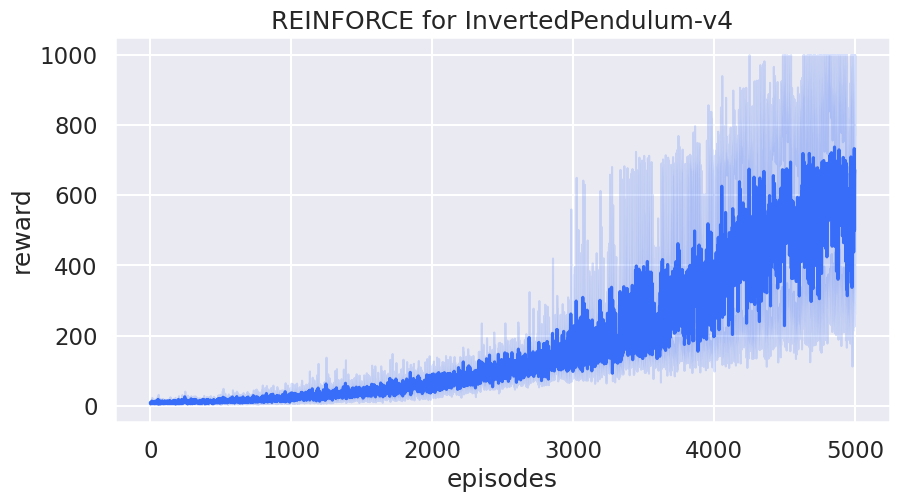

In [9]:
df1 = pd.DataFrame(rewards_over_seeds).melt()  # преобразуем данные в формат DataFrame для построения графика
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)  # переименовываем столбцы

sns.set(style="darkgrid", context="talk", palette="rainbow")  # задаем стиль графика
sns.lineplot(x="episodes", y="reward", data=df1).set(title="REINFORCE for InvertedPendulum-v4")  # строим график обучения

plt.show()  # отображаем график

## Литература

[1] Williams, Ronald J.. “Simple statistical gradient-following
algorithms for connectionist reinforcement learning.” Machine Learning 8 (2004): 229-256.




# Задание для самостоятельного выполнения

1.Выполнить код приведенный выше.

2.Пояснить каждую строку кода. Для этого около каждой строки приписать коментарий, поясняющий что делает эта строка кода.  